Import libraries

In [44]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


Load data from SQLite

In [45]:
conn = sqlite3.connect("../database/medsupply.db")

query = "SELECT * FROM sales"
df = pd.read_sql(query, conn)

conn.close()

df.head()


,date,Year,Month,Weekday Name,product,units_sold
0,2014-01-03 00:00:00,2014,1,Friday,M01AB,8.00
1,2014-01-04 00:00:00,2014,1,Saturday,M01AB,2.00
2,2014-01-05 00:00:00,2014,1,Sunday,M01AB,4.00
3,2014-01-06 00:00:00,2014,1,Monday,M01AB,5.00
4,2014-01-08 00:00:00,2014,1,Wednesday,M01AB,5.33


Basic inspection

In [46]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (14455, 6)

Columns:
Index(['date', 'Year', 'Month', 'Weekday Name', 'product', 'units_sold'], dtype='object')

Data Types:
date             object
Year              int64
Month             int64
Weekday Name     object
product          object
units_sold      float64
dtype: object

Missing Values:
date            0
Year            0
Month           0
Weekday Name    0
product         0
units_sold      0
dtype: int64


Covert date column

In [47]:
df["date"] = pd.to_datetime(df["date"])

In [48]:
print(df.dtypes)

date            datetime64[ns]
Year                     int64
Month                    int64
Weekday Name            object
product                 object
units_sold             float64
dtype: object


overall demand trend

In [49]:
daily = df.groupby("date")["units_sold"].sum().reset_index()
print(daily.head())

        date  units_sold
0 2014-01-02       48.47
1 2014-01-03      107.00
2 2014-01-04       91.35
3 2014-01-05       66.10
4 2014-01-06       58.20


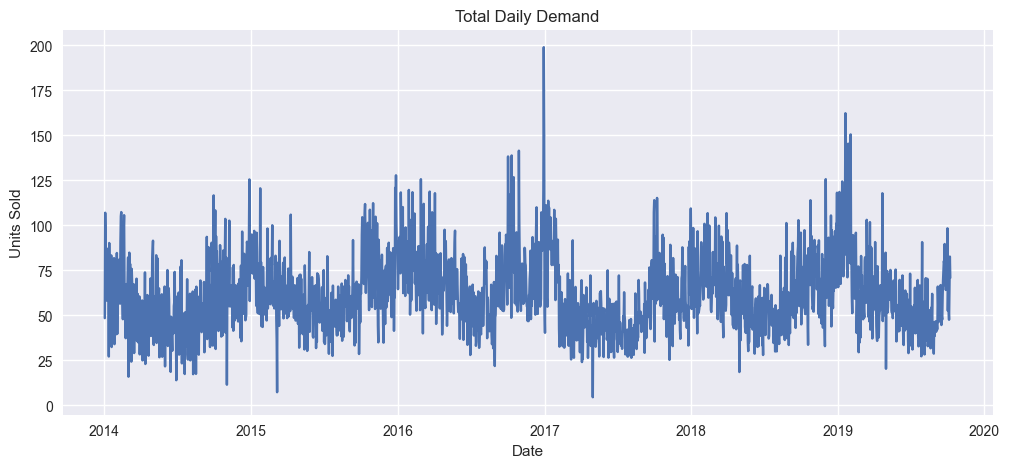

In [50]:
plt.figure(figsize=(12,5))
plt.plot(daily["date"], daily["units_sold"])         #, marker="o", linestyle= "None")
plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

Demand per product

In [51]:
product_totals = df.groupby("product")["units_sold"].sum().sort_values(ascending=False)
print(product_totals.head())

product
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
Name: units_sold, dtype: float64


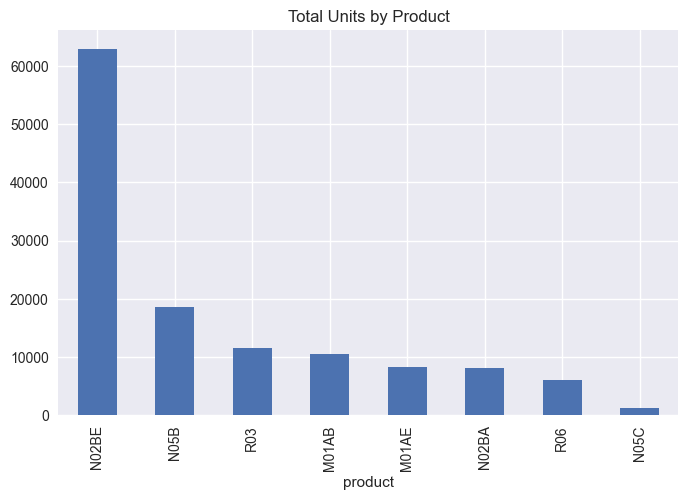

In [52]:
plt.figure(figsize=(8,5))
product_totals.plot(kind="bar")
plt.title("Total Units by Product")
plt.show()

Monthly seasonality

In [53]:
df["year_month"] = df["date"].dt.to_period("M")

monthly = df.groupby("year_month")["units_sold"].sum().reset_index()
print(monthly.head())


  year_month  units_sold
0    2014-01    1801.110
1    2014-02    1974.470
2    2014-03    1606.720
3    2014-04    1423.925
4    2014-05    1506.303


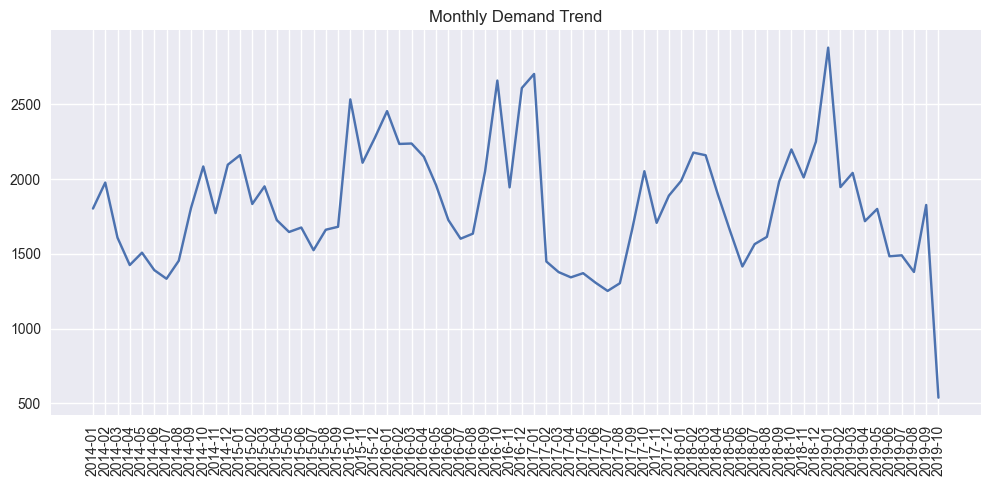

In [54]:
plt.figure(figsize=(12,5))
plt.plot(monthly["year_month"].astype(str), monthly["units_sold"])
plt.xticks(rotation=90)
plt.title("Monthly Demand Trend")
plt.show()

Weekday pattern

In [55]:
weekday = df.groupby("Weekday Name")["units_sold"].mean()
print(weekday.head())

weekday = weekday.reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])
print(weekday.head())

Weekday Name
Friday      8.656082
Monday      8.817214
Saturday    9.508222
Sunday      9.209929
Thursday    8.466497
Name: units_sold, dtype: float64
Weekday Name
Monday       8.817214
Tuesday      8.614805
Wednesday    8.527604
Thursday     8.466497
Friday       8.656082
Name: units_sold, dtype: float64


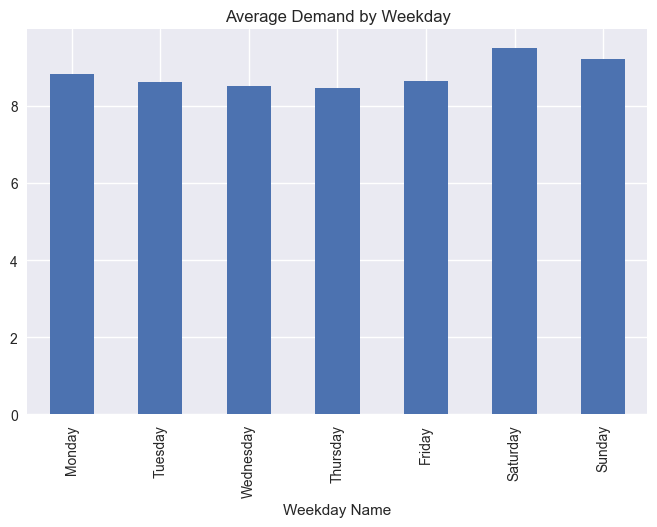

In [56]:
plt.figure(figsize=(8,5))
weekday.plot(kind="bar")
plt.title("Average Demand by Weekday")
plt.show()


Product trend comparison

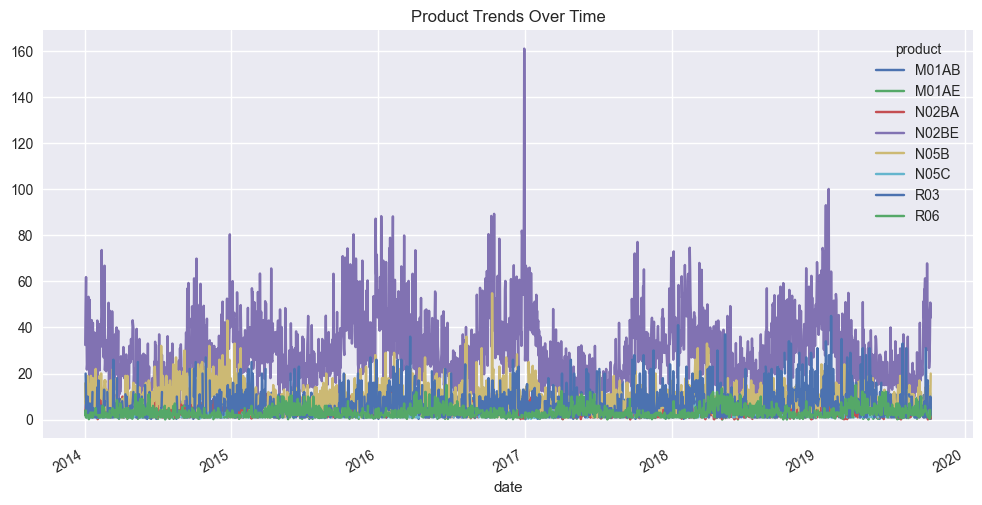

In [57]:
pivot = df.pivot_table(index="date", columns="product", values="units_sold", aggfunc="sum")

pivot.plot(figsize=(12,6))
plt.title("Product Trends Over Time")
plt.show()

Correlation heatmap

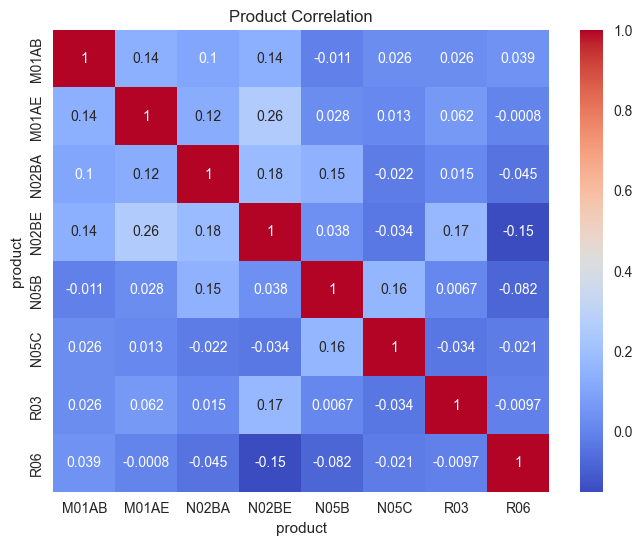

In [58]:
corr = pivot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Product Correlation")
plt.show()


Outlier detection

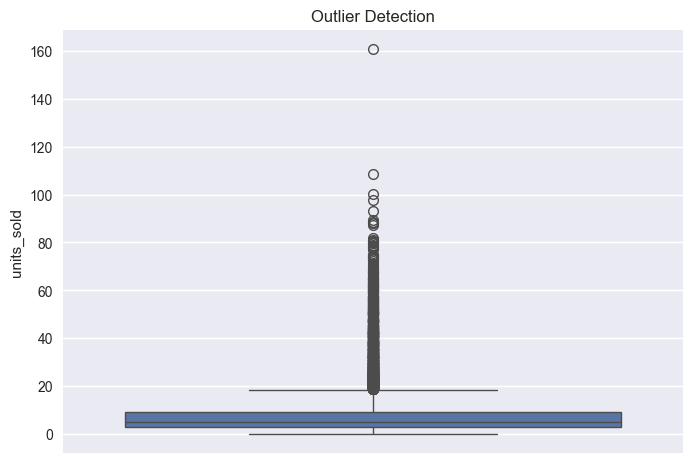

In [59]:
sns.boxplot(y=df["units_sold"])
plt.title("Outlier Detection")
plt.show()

In [60]:
df.head()

,date,Year,Month,Weekday Name,product,units_sold,year_month
0,2014-01-03,2014,1,Friday,M01AB,8.00,2014-01
1,2014-01-04,2014,1,Saturday,M01AB,2.00,2014-01
2,2014-01-05,2014,1,Sunday,M01AB,4.00,2014-01
3,2014-01-06,2014,1,Monday,M01AB,5.00,2014-01
4,2014-01-08,2014,1,Wednesday,M01AB,5.33,2014-01


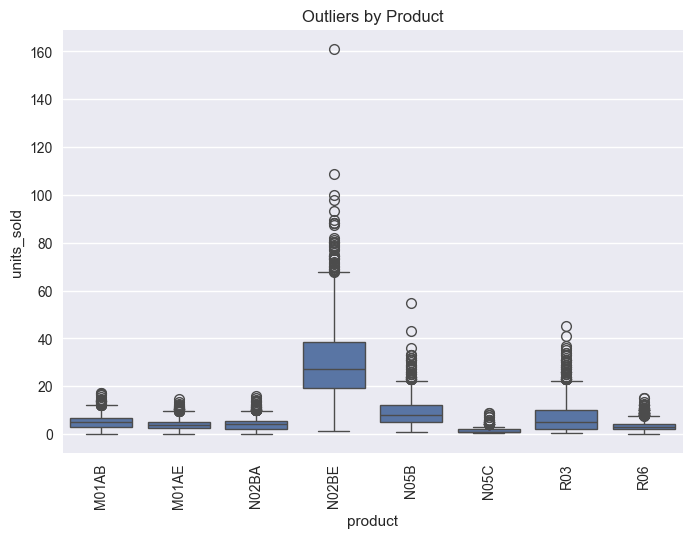

In [61]:
sns.boxplot(x="product", y="units_sold", data=df)
plt.xticks(rotation=90)
plt.title("Outliers by Product")
plt.show()

since there are many outliers and it is affecting the relative error being very high for some products, we will cap the outliers at the 99th percentile for each product to reduce their impact on the model.

In [62]:
# Check upper bound
upper_limit = df["units_sold"].quantile(0.99)

print("Upper cap:", upper_limit)

# Cap values
df["units_sold"] = df["units_sold"].clip(upper=upper_limit)

Upper cap: 55.67947999999997


log transformation, because the data is skewed

In [63]:
import numpy as np

df["units_sold_log"] = np.log1p(df["units_sold"])

Feature Engineering + ML model 

fe.1 Prepare data for ML

In [82]:
# Sort data
df = df.sort_values(["product", "date"])

# ---------- BASIC LAGS ----------
df["lag_1"] = df.groupby("product")["units_sold"].shift(1)
df["lag_2"] = df.groupby("product")["units_sold"].shift(2)
df["lag_3"] = df.groupby("product")["units_sold"].shift(3)
df["lag_7"] = df.groupby("product")["units_sold"].shift(7)

# ---------- ROLLING FEATURES ----------
df["rolling_3"] = df.groupby("product")["units_sold"].rolling(3).mean().reset_index(0, drop=True)
df["rolling_7"] = df.groupby("product")["units_sold"].rolling(7).mean().reset_index(0, drop=True)
df["rolling_14"] = df.groupby("product")["units_sold"].rolling(14).mean().reset_index(0, drop=True)

# Rolling std (captures volatility)
df["rolling_std_7"] = df.groupby("product")["units_sold"].rolling(7).std().reset_index(0, drop=True)

# ---------- CALENDAR FEATURES ----------
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

# Weekend flag
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

# ---------- TREND FEATURES ----------
# Expanding mean (overall trend)
df["expanding_mean"] = df.groupby("product")["units_sold"].expanding().mean().reset_index(0, drop=True)
# Shift to avoid data leakage (use only past data for prediction)
df["expanding_mean"] = df.groupby("product")["expanding_mean"].shift(1)

# ---------- TARGET SHIFT ----------
# Next day demand prediction target
df["target"] = df.groupby("product")["units_sold"].shift(-1)

# ---------- DROP NA ----------
df_model = df.dropna()

df_model.head()

,date,Year,Month,Weekday Name,product,units_sold,year_month,units_sold_log,lag_1,lag_2,...,rolling_7,rolling_14,rolling_std_7,day_of_week,month,day_of_month,week_of_year,is_weekend,expanding_mean,target
13,2014-01-17,2014,1,Friday,M01AB,2.00,2014-01,1.098612,6.00,4.00,...,4.620000,4.905000,2.060129,4,1,17,3,0,5.128462,1.00
14,2014-01-18,2014,1,Saturday,M01AB,1.00,2014-01,0.693147,2.00,6.00,...,4.048571,4.405000,2.454217,5,1,18,3,1,4.905000,4.33
15,2014-01-19,2014,1,Sunday,M01AB,4.33,2014-01,1.673351,1.00,2.00,...,4.381429,4.571429,2.282034,6,1,19,3,1,4.644667,6.00
16,2014-01-20,2014,1,Monday,M01AB,6.00,2014-01,1.945910,4.33,1.00,...,4.190000,4.714286,2.035362,0,1,20,4,0,4.625000,2.00
17,2014-01-21,2014,1,Tuesday,M01AB,2.00,2014-01,1.098612,6.00,4.33,...,3.618571,4.500000,2.003767,1,1,21,4,0,4.705882,7.00


fe.11 - (That one product alone is pulling overall MAE up.) and (The model does not properly differentiate product behavior.) 

Add Product One-Hot Encoding

In [83]:
# One-hot encode product
df_model = pd.get_dummies(df_model, columns=["product"], drop_first=False)

# Extract product columns
product_cols = [c for c in df_model.columns if c.startswith("product_")]

print("Product columns created:", product_cols)

Product columns created: ['product_M01AB', 'product_M01AE', 'product_N02BA', 'product_N02BE', 'product_N05B', 'product_N05C', 'product_R03', 'product_R06']


In [84]:
df_model.head()

,date,Year,Month,Weekday Name,units_sold,year_month,units_sold_log,lag_1,lag_2,lag_3,...,expanding_mean,target,product_M01AB,product_M01AE,product_N02BA,product_N02BE,product_N05B,product_N05C,product_R03,product_R06
13,2014-01-17,2014,1,Friday,2.00,2014-01,1.098612,6.00,4.00,6.0,...,5.128462,1.00,True,False,False,False,False,False,False,False
14,2014-01-18,2014,1,Saturday,1.00,2014-01,0.693147,2.00,6.00,4.0,...,4.905000,4.33,True,False,False,False,False,False,False,False
15,2014-01-19,2014,1,Sunday,4.33,2014-01,1.673351,1.00,2.00,6.0,...,4.644667,6.00,True,False,False,False,False,False,False,False
16,2014-01-20,2014,1,Monday,6.00,2014-01,1.945910,4.33,1.00,2.0,...,4.625000,2.00,True,False,False,False,False,False,False,False
17,2014-01-21,2014,1,Tuesday,2.00,2014-01,1.098612,6.00,4.33,1.0,...,4.705882,7.00,True,False,False,False,False,False,False,False


fe.2 Define X and y

In [85]:
base_features = [
    "lag_1","lag_2","lag_3","lag_7",
    "rolling_3","rolling_7","rolling_14",
    "rolling_std_7",
    "day_of_week","month","day_of_month","week_of_year","is_weekend",
    "expanding_mean"
]

features = base_features + product_cols

X = df_model[features]
Y = df_model["target"]

fe.3 split data (time based)

In [86]:
split_date = df_model["date"].quantile(0.8)

train = df_model[df_model["date"] <= split_date]
test = df_model[df_model["date"] > split_date]

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

fe.4 Metrics we will use 

In [87]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate(y_true, y_pred, name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    m = mape(y_true, y_pred)
    print(f"\n{name}")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2  : {r2:.3f}")
    print(f"MAPE: {m:.2f}%")
    return {"model": name, "mae": mae, "rmse": rmse, "r2": r2, "mape": m}

fe.5 Baseline model - Linear Regression

In [88]:
from sklearn.linear_model import LinearRegression  

lr = LinearRegression()
# “Look at these features (X_train) and learn how they relate to the correct answers (y_train).”
lr.fit(X_train, y_train)
y_predlr = lr.predict(X_test)

res_lr = evaluate(y_test, y_predlr, "Linear Regression Baseline")


Linear Regression Baseline
MAE : 3.308
RMSE: 5.273
R2  : 0.769
MAPE: 82.68%


fe.6 Random FOrest 

In [89]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_predrf = rf.predict(X_test)
res_rf = evaluate(y_test, y_predrf, "Random Forest")


Random Forest
MAE : 3.372
RMSE: 5.323
R2  : 0.765
MAPE: 90.10%


fe.7 Gradient Boosting Regressor 

In [90]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_predgbr = gbr.predict(X_test)
res_gbr = evaluate(y_test, y_predgbr, "Gradient Boosting")


Gradient Boosting
MAE : 3.285
RMSE: 5.221
R2  : 0.774
MAPE: 85.72%


fe8. Compare results in a table

In [91]:
import pandas as pd

results = pd.DataFrame([res_lr, res_rf, res_gbr]).sort_values("mae")
results

,model,mae,rmse,r2,mape
2,Gradient Boosting,3.284964,5.220699,0.773519,85.716296
0,Linear Regression Baseline,3.307992,5.273060,0.768953,82.676245
1,Random Forest,3.371549,5.323473,0.764514,90.098775


fe8. small but important checks 

a) plot actual vs predicted (sanity)

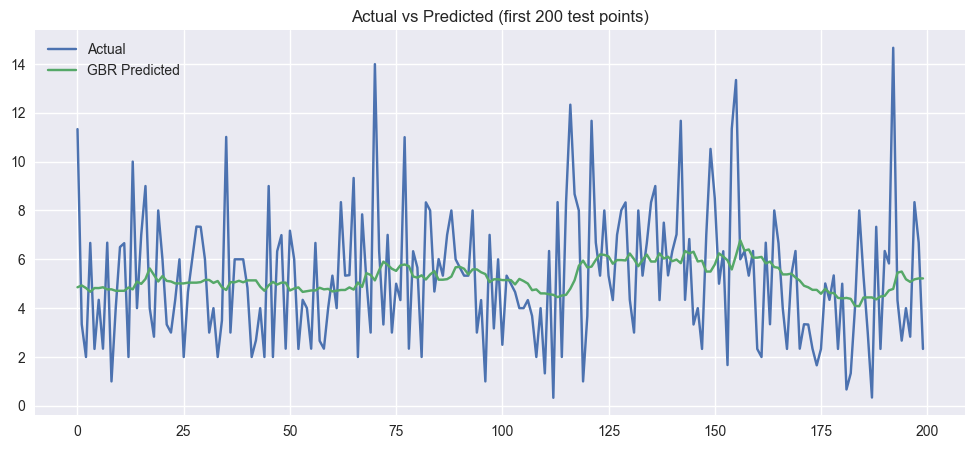

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_predgbr[:200], label="GBR Predicted")
plt.legend()
plt.title("Actual vs Predicted (first 200 test points)")
plt.show()

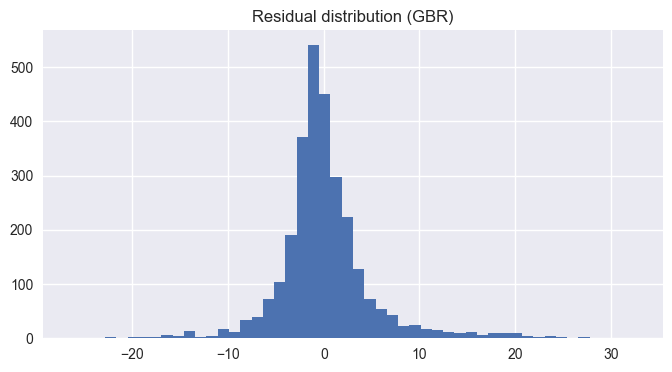

In [93]:
residuals = y_test.values - y_predgbr
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50)
plt.title("Residual distribution (GBR)")
plt.show()

fe.9 create a proper "result summary" + MAE% (clean reporting)

In [94]:
print("Average demand:", y_test.mean())
print("GBR MAE:", res_gbr["mae"])
print("MAE as % of demand:", res_gbr["mae"] / y_test.mean())

Average demand: 8.929338027711141
GBR MAE: 3.2849641663552176
MAE as % of demand: 0.3678844004069194


fe.10. Per-product performance (this tells if one product is causing most error.)

In [95]:
# 1) Start from your test set
test_eval = test.copy()

# 2) Add predictions
test_eval["pred_gbr"] = y_predgbr

# 3) Absolute error
test_eval["abs_error"] = (test_eval["target"] - test_eval["pred_gbr"]).abs()

# 4) Reconstruct product label from one-hot columns
prod_cols = [c for c in test_eval.columns if c.startswith("product_")]
test_eval["product"] = (
    test_eval[prod_cols]
    .idxmax(axis=1)
    .str.replace("product_", "", regex=False)
)

# 5) Per-product performance
prod_perf = (
    test_eval.groupby("product")
    .agg(
        avg_actual=("target", "mean"),
        mae=("abs_error", "mean"),
        count=("abs_error", "count")
    )
    .sort_values("mae", ascending=False)
)

prod_perf

,avg_actual,mae,count
product,,,
N02BE,30.465775,8.077261,402
R03,9.116643,5.747812,349
N05B,8.743284,3.221498,402
M01AB,5.400274,2.160010,401
M01AE,3.916287,1.613741,400
R06,3.698556,1.613470,367
N02BA,3.223643,1.555532,387
N05C,1.832258,0.973999,155


In [96]:
print("Worst 3 products by MAE:")
display(prod_perf.head(3))

print("\nBest 3 products by MAE:")
display(prod_perf.tail(3))

Worst 3 products by MAE:


,avg_actual,mae,count
product,,,
N02BE,30.465775,8.077261,402
R03,9.116643,5.747812,349
N05B,8.743284,3.221498,402



Best 3 products by MAE:


,avg_actual,mae,count
product,,,
R06,3.698556,1.613470,367
N02BA,3.223643,1.555532,387
N05C,1.832258,0.973999,155


<Axes: title={'center': 'MAE by Product (GBR)'}, xlabel='product'>

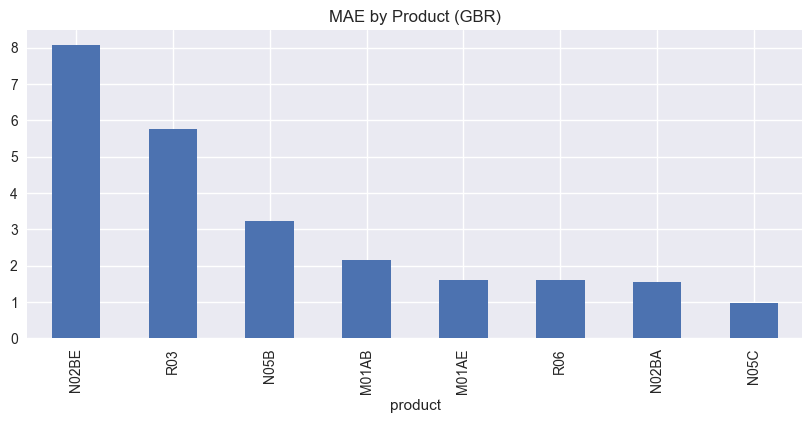

In [97]:
prod_perf["mae"].plot(kind="bar", figsize=(10,4), title="MAE by Product (GBR)")

In [100]:
# Naive baseline: tomorrow = today
naive_pred = test["lag_1"]   # already in actual scale

# Evaluate directly (no expm1 needed)
res_naive = evaluate(y_test, naive_pred, "Naive baseline (lag_1)")


Naive baseline (lag_1)
MAE : 4.301
RMSE: 6.952
R2  : 0.598
MAPE: 95.81%


In [101]:
comparison = pd.DataFrame([res_naive, res_lr, res_rf, res_gbr]).sort_values("mae")
comparison

,model,mae,rmse,r2,mape
3,Gradient Boosting,3.284964,5.220699,0.773519,85.716296
1,Linear Regression Baseline,3.307992,5.273060,0.768953,82.676245
2,Random Forest,3.371549,5.323473,0.764514,90.098775
0,Naive baseline (lag_1),4.300568,6.952162,0.598381,95.812913


“I validated my model against a naive baseline and achieved ~24% improvement, confirming the model captures meaningful temporal patterns.”

Light tunining (light because model is already beating the naive baseline by ~24%)

In [102]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_tuned = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_tuned.fit(X_train, y_train)

y_pred_tuned = gbr_tuned.predict(X_test)

res_gbr_tuned = evaluate(y_test, y_pred_tuned, "GBR Tuned")


GBR Tuned
MAE : 3.259
RMSE: 5.202
R2  : 0.775
MAPE: 84.41%


save final model 

In [103]:
import joblib
import os
import json

os.makedirs("../outputs", exist_ok=True)

# Save tuned model
joblib.dump(gbr_tuned, "../outputs/demand_model.pkl")

# Save feature list
with open("../outputs/features.json", "w") as f:
    json.dump(features, f)

print("Final tuned model saved ✅")

Final tuned model saved ✅


Problem Statement
Built a demand forecasting model to predict next-day sales for multiple pharmaceutical products using historical time-series data.

🔹 Key Observations from EDA

Demand shows clear weekly seasonality (higher on weekends).

Certain products (e.g., N02BE) dominate overall demand.

Presence of extreme spikes (outliers) in high-demand products.

Different products have very different demand scales.


🔹 Feature Engineering Strategy

Created lag features (lag_1, lag_7) to capture past behavior.

Used rolling averages (7-day, 14-day) to capture trends.

Added calendar features (weekday, month, weekend).

Included product encoding to differentiate product behavior.

Prevented data leakage using proper shifting.


🔹 Model Comparison

Tested:

Linear Regression (baseline)

Random Forest

Gradient Boosting

Gradient Boosting performed best based on MAE.


🔹 Data Quality Improvements

Applied outlier capping (99th percentile) to stabilize model.

Tested log transformation but retained capped data due to better RMSE.


🔹 Model Validation

Compared against naive baseline (lag_1):

Naive MAE ≈ 4.3

Final model MAE ≈ 3.26

Achieved ~24% improvement over baseline, confirming model effectiveness.


🔹 Final Model

Selected tuned Gradient Boosting Regressor

Metrics:

MAE ≈ 3.26

RMSE ≈ 5.20

R² ≈ 0.77


🔹 Key Learnings

Feature engineering contributed more than model complexity.

Handling outliers significantly improved performance.

Model performance varies across products → need segmentation awareness.

Simple baselines are critical for validating ML models.
